In [1]:
# Intertemporal Choice: Do LLMs Discount the Future Like Humans?
### CPSY 1950 — Deep Learning in Brains, Minds & Machines

**Experiment:** Ruggeri et al. (2022) — Globalizability of intertemporal choice  
**Dataset:** Psych-101 (Binz et al., 2024) — `ruggeri2022globalizability/exp1.csv`  
**Models tested:** Llama-3.3-70B-Instruct, Mistral-Large-3 (+ frontier models after Apr 5)

---

This notebook runs a behavioral experiment on large language models, treating them
as cognitive subjects — the same way psychologists run experiments on human participants.

**The core question:** When humans choose between a smaller reward now and a larger
reward later, they show systematic, irrational impatience. Do LLMs reproduce the same
behavioral signature — or do they discount differently?

**Why it matters:** LLMs have read millions of words *describing* human decision-making
biases, but have never actually waited for anything. This experiment tests whether
formally knowing about a cognitive bias (Mahowald et al., 2024) is the same as
functionally exhibiting it.

SyntaxError: invalid character '—' (U+2014) (3260561807.py, line 4)

In [ ]:
## Cell 2 — API Setup

We connect to Brown's LiteLLM endpoint, which proxies access to all course models
(Llama, Mistral, and frontier models after TA review).

The API key is loaded from a `.env` file in this directory — never hardcoded —
following standard security practice. You must be on Brown VPN for this to connect.

**Models available:**
- `Llama-3.3-70B-Instruct` — open-weight, supports logprobs → NLL scores possible
- `Mistral-Large-3` — open-weight, binary choice only (no logprobs on this endpoint)
- Frontier models (Claude, GPT) — unlocked after draft poster submission Apr 5

In [12]:
from dotenv import load_dotenv
import os
from openai import OpenAI

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

print("Connected. API key loaded:", os.getenv("OPENAI_API_KEY") is not None)
# ── Check what frontier models are available on the endpoint ──
models = client.models.list()
for model in models.data:
    print(model.id)

Connected. API key loaded: True
gemini-3-flash-preview
claude-sonnet-4-5
gpt-5.4
gpt-oss
Llama-3.3-70B-Instruct
Mistral-Large-3
gpt-5.2
gpt-5.2-codex
gemini-2.5-pro
gemini-3.1-flash-lite-preview


In [ ]:
## Cell 4 — Load Dataset

We load **Psych-101** (Binz et al., 2024), a dataset of natural language transcripts
from 160 psychological experiments across 60,092 human participants.

**Our experiment:** `ruggeri2022globalizability/exp1.csv`
Source: Ruggeri et al. (2022), *Nature Human Behaviour* — a large-scale cross-cultural
study of intertemporal choice across 61 countries and 13,629 participants.

Each row is one participant's complete session. The prompts are already formatted as
natural language — the same format we send to LLMs — and the human response data is
built in, giving us a direct comparison baseline.

**Experiment structure:** Participants chose between a smaller-sooner (SS) and
larger-later (LL) reward across 10 trials, varying:
- Gains vs. losses (sign effect)
- Small ($500) vs. large ($5000) amounts (magnitude effect)
- 1-year vs. 2-year delays

In [3]:
from datasets import load_dataset

dataset = load_dataset("marcelbinz/Psych-101", split="train")

EXPERIMENT = "ruggeri2022globalizability/exp1.csv"
itc_data = dataset.filter(lambda row: row["experiment"] == EXPERIMENT)

print(f"Experiment: {EXPERIMENT}")
print(f"Number of participants: {len(itc_data)}")

# Print the first participant's full session so we can see the prompt structure
print("\n── SAMPLE PROMPT (Participant 0) ──")
print(itc_data[0]["text"])

Experiment: ruggeri2022globalizability/exp1.csv
Number of participants: 11937

── SAMPLE PROMPT (Participant 0) ──
In the following you will be presented with multiple choices between two options G and C.
Please name which option you would prefer by pressing the corresponding key.

You have the choice between receiving 500$ immediately (press G) or receiving 550$ in one year (press C). You press <<G>>.
You have the choice between receiving 500$ immediately (press G) or receiving 600$ in one year (press C). You press <<C>>.
You have the choice between paying 500$ immediately (press G) or paying 550$ in one year (press C). You press <<G>>.
You have the choice between paying 500$ immediately (press G) or paying 510$ in one year (press C). You press <<C>>.
You have the choice between receiving 5000$ immediately (press G) or receiving 5500$ in one year (press C). You press <<G>>.
You have the choice between receiving 5000$ immediately (press G) or receiving 6000$ in one year (press C). You 

In [ ]:
## Cell 6 — All Function Definitions

This single cell defines every function used in the notebook.
It is always safe to run — no API calls are made here.

**On kernel restart:** Run this cell before any analysis or experiment cell.

Functions are organized into four groups:
1. Parsing helpers — split sessions into trials, extract metadata
2. Model querying — send prompts to API, retrieve choices and logprobs
3. NLL computation — score model alignment against human choices
4. Experiment runners — orchestrate full 50-participant runs
5. Zorbs manipulation — convert prompts and run the contamination test

In [21]:
import re
import math
import pandas as pd
from tqdm import tqdm

# ════════════════════════════════════════════
# GROUP 1 — PARSING HELPERS
# ════════════════════════════════════════════

def extract_trials(text):
    """
    Splits one participant's session into individual trials.
    Returns list of (prompt, human_choice) tuples.
    Each prompt includes the full running context of all prior trials.
    """
    trials = []
    pattern = r'(.*?)(<<[A-Z]>>)'
    matches = re.findall(pattern, text, re.DOTALL)
    running_context = ""
    for context_piece, choice in matches:
        running_context += context_piece
        prompt = running_context.strip()
        human_answer = choice.replace("<<", "").replace(">>", "")
        trials.append((prompt, human_answer))
        running_context += choice
    return trials


def get_valid_options(prompt):
    """Extract the valid letter options from a prompt (handles randomization)."""
    options = re.findall(r'\(press ([A-Z])\)', prompt)
    return list(set(options))


def get_immediate_option(prompt):
    """Return the letter corresponding to the immediate reward option."""
    match = re.search(r'immediately \(press ([A-Z])\)', prompt)
    return match.group(1) if match else None


def get_trial_type(prompt):
    """Classify each trial by sign (gain/loss) and amount (small/large)."""
    last_trial = prompt.split('\n')[-1] if '\n' in prompt else prompt
    sign = 'loss' if 'paying' in last_trial.lower() else 'gain'
    amount = 'large' if '5000' in last_trial else 'small'
    if 'in one year' in last_trial and 'immediately' not in last_trial:
        delay = 'future-future'
    elif 'in two years' in last_trial and 'immediately' in last_trial:
        delay = '2-year'
    else:
        delay = '1-year'
    return sign, amount, delay


# ════════════════════════════════════════════
# GROUP 2 — MODEL QUERYING
# ════════════════════════════════════════════

def ask_model_with_logprobs(prompt, model_name):
    """
    Send a prompt to a model that supports logprobs (Llama).
    Returns (chosen_letter, logprob_dict).
    """
    valid_options = get_valid_options(prompt)
    options_str = " or ".join(valid_options)

    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": (f"You are participating in a psychology experiment. "
                            f"You must respond with ONLY a single letter ({options_str}). "
                            f"No explanation. No punctuation. Just the letter.")
            },
            {
                "role": "user",
                "content": prompt + "\nYou press <<"
            }
        ],
        max_tokens=3,
        max_completion_tokens=3,
        temperature=0.0,
        logprobs=True,
        top_logprobs=5
    )

    raw = response.choices[0].message.content.strip()
    chosen = None
    for char in raw:
        if char in valid_options:
            chosen = char
            break

    logprob_dict = {}
    if response.choices[0].logprobs:
        for token_logprob in response.choices[0].logprobs.content:
            main_token = token_logprob.token.strip()
            if main_token in valid_options:
                logprob_dict[main_token] = token_logprob.logprob
            for top in token_logprob.top_logprobs:
                cleaned = top.token.strip()
                if cleaned in valid_options and cleaned not in logprob_dict:
                    logprob_dict[cleaned] = top.logprob

    # If one option missing from logprobs, assign a very low probability
    if len(logprob_dict) == 1 and len(valid_options) == 2:
        missing = [o for o in valid_options if o not in logprob_dict][0]
        logprob_dict[missing] = -10.0

    return chosen, logprob_dict


def ask_model_choice_only(prompt, model_name):
    """
    Send a prompt to a model without logprobs (Mistral, frontier).
    Returns chosen_letter only.
    """
    valid_options = get_valid_options(prompt)
    options_str = " or ".join(valid_options)

    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": (f"You are participating in a psychology experiment. "
                            f"You must respond with ONLY a single letter ({options_str}). "
                            f"No explanation. No punctuation. Just the letter.")
            },
            {
                "role": "user",
                "content": prompt + "\nYou press <<"
            }
        ],
        max_tokens=3,
        max_completion_tokens=3,
        temperature=0.0
    )

    raw = response.choices[0].message.content.strip()
    for char in raw:
        if char in valid_options:
            return char
    return None


# ════════════════════════════════════════════
# GROUP 3 — NLL COMPUTATION
# ════════════════════════════════════════════

def compute_nll(human_choice, logprob_dict):
    """
    Compute negative log-likelihood of the human's actual choice
    given the model's probability distribution.
    Lower NLL = model assigned more probability to what the human chose.
    """
    if human_choice in logprob_dict:
        return -logprob_dict[human_choice]
    return None


# ════════════════════════════════════════════
# GROUP 4 — EXPERIMENT RUNNERS (MONEY CONDITION)
# ════════════════════════════════════════════

def run_experiment_with_nll(data, model_name, n_participants=50):
    """Run money condition for Llama (with NLL)."""
    results = []
    for i in tqdm(range(n_participants), desc=f"Running {model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            chosen, logprob_dict = ask_model_with_logprobs(prompt, model_name)
            nll = compute_nll(human_choice, logprob_dict)
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "condition": "money",
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": prompt,
                "nll": nll,
            })
    return pd.DataFrame(results)


def run_experiment_choice_only(data, model_name, n_participants=50):
    """Run money condition for Mistral/frontier (binary choice only)."""
    results = []
    for i in tqdm(range(n_participants), desc=f"Running {model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            chosen = ask_model_choice_only(prompt, model_name)
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "condition": "money",
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": prompt,
                "nll": None,
            })
    return pd.DataFrame(results)


# ════════════════════════════════════════════
# GROUP 5 — ZORBS CONDITION
# ════════════════════════════════════════════

def convert_to_zorbs(prompt):
    """
    Replace all dollar amounts with zorbs.
    $500 → 500 zorbs. 500$ → 500 zorbs. Everything else unchanged.
    """
    zorbs_prompt = re.sub(r'\$(\d+)', r'\1 zorbs', prompt)
    zorbs_prompt = re.sub(r'(\d+)\$', r'\1 zorbs', zorbs_prompt)
    zorbs_prompt = zorbs_prompt.replace('$', ' zorbs')
    return zorbs_prompt


def run_experiment_zorbs_nll(data, model_name, n_participants=50):
    """Run zorbs condition for Llama (with NLL)."""
    results = []
    for i in tqdm(range(n_participants), desc=f"Zorbs/{model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            zorbs_prompt = convert_to_zorbs(prompt)
            chosen, logprob_dict = ask_model_with_logprobs(zorbs_prompt, model_name)
            nll = compute_nll(human_choice, logprob_dict) if logprob_dict else None
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "condition": "zorbs",
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": zorbs_prompt,
                "nll": nll,
            })
    return pd.DataFrame(results)


def run_experiment_zorbs_choice_only(data, model_name, n_participants=50):
    """Run zorbs condition for Mistral/frontier (binary choice only)."""
    results = []
    for i in tqdm(range(n_participants), desc=f"Zorbs/{model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            zorbs_prompt = convert_to_zorbs(prompt)
            chosen = ask_model_choice_only(zorbs_prompt, model_name)
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "condition": "zorbs",
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": zorbs_prompt,
                "nll": None,
            })
    return pd.DataFrame(results)


print("All functions defined successfully.")

# ════════════════════════════════════════════
# GROUP 6 — FRONTIER MODEL QUERYING
# (no temperature parameter — GPT-5.x and Claude don't accept it)
# ════════════════════════════════════════════

def ask_frontier_model(prompt, model_name):
    """
    Like ask_model_choice_only but without temperature=0.0.
    Required for GPT-5.x reasoning models which reject that parameter.
    Claude also works fine without it.
    """
    valid_options = get_valid_options(prompt)
    options_str = " or ".join(valid_options)

    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": (f"You are participating in a psychology experiment. "
                            f"You must respond with ONLY a single letter ({options_str}). "
                            f"No explanation. No punctuation. Just the letter.")
            },
            {
                "role": "user",
                "content": prompt + "\nYou press <<"
            }
        ],
        max_tokens=50,
        temperature=1
    )

    raw = response.choices[0].message.content.strip()
    for char in raw:
        if char in valid_options:
            return char
    return None


def run_experiment_frontier(data, model_name, n_participants=50):
    """Money condition runner for frontier models."""
    results = []
    for i in tqdm(range(n_participants), desc=f"Running {model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            chosen = ask_frontier_model(prompt, model_name)
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "condition": "money",
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": prompt,
                "nll": None,
            })
    return pd.DataFrame(results)


def run_experiment_zorbs_frontier(data, model_name, n_participants=50):
    """Zorbs condition runner for frontier models."""
    results = []
    for i in tqdm(range(n_participants), desc=f"Zorbs/{model_name}"):
        participant_trials = extract_trials(data[i]["text"])
        for trial_idx, (prompt, human_choice) in enumerate(participant_trials):
            zorbs_prompt = convert_to_zorbs(prompt)
            chosen = ask_frontier_model(zorbs_prompt, model_name)
            results.append({
                "participant": i,
                "trial": trial_idx,
                "model_name": model_name,
                "condition": "zorbs",
                "human_choice": human_choice,
                "model_choice": chosen,
                "prompt": zorbs_prompt,
                "nll": None,
            })
    return pd.DataFrame(results)

print("Frontier functions defined.")

All functions defined successfully.
Frontier functions defined.


In [ ]:
## ⚠️ CELLS 8 & 9 — SKIP ON RESTART

These cells ran the money condition API calls for Llama and Mistral.
Results are already saved to CSV. Never run these again unless starting fresh.

In [ ]:
# ⚠️ SKIP — Already collected. Results saved to results_llama_50p.csv
# df_llama_full = run_experiment_with_nll(itc_data, "Llama-3.3-70B-Instruct", n_participants=50)
# df_llama_full.to_csv("results_llama_50p.csv", index=False)

In [ ]:
# ⚠️ SKIP — Already collected. Results saved to results_mistral_50p.csv
# df_mistral_full = run_experiment_choice_only(itc_data, "Mistral-Large-3", n_participants=50)
# df_mistral_full.to_csv("results_mistral_50p.csv", index=False)

In [ ]:
## Cell 11 — Load All Results From CSV

On every kernel restart, run this cell to restore all four dataframes from disk.
This replaces re-running any API call cells above.

In [9]:
# ── Load all saved results ──
df_llama_full   = pd.read_csv("results_llama_50p.csv")
df_mistral_full = pd.read_csv("results_mistral_50p.csv")
df_llama_zorbs  = pd.read_csv("results_llama_zorbs_50p.csv")
df_mistral_zorbs = pd.read_csv("results_mistral_zorbs_50p.csv")

print(f"Llama money:    {len(df_llama_full)} trials")
print(f"Mistral money:  {len(df_mistral_full)} trials")
print(f"Llama zorbs:    {len(df_llama_zorbs)} trials")
print(f"Mistral zorbs:  {len(df_mistral_zorbs)} trials")

Llama money:    598 trials
Mistral money:  598 trials
Llama zorbs:    598 trials
Mistral zorbs:  598 trials


In [ ]:
## ⚠️ CELLS 13 & 14 — SKIP ON RESTART

These cells ran the zorbs condition API calls.
Once complete, results are saved to CSV. Never run again unless starting fresh.

In [ ]:
## Cell 14 — Money vs Zorbs: Comparison Analysis

### What this cell does

This is the scientific payoff of the zorbs manipulation. We now have four datasets:
- Llama on money condition (598 trials)
- Mistral on money condition (598 trials)
- Llama on zorbs condition (598 trials)
- Mistral on zorbs condition (598 trials)

We compute patience rates for each dataset across all three conditions
(overall, sign effect, magnitude effect) and then compare money vs zorbs
side by side for each model.

### How to interpret the results

**If patience rates are stable across money and zorbs:**
The model's behavior is robust. It was computing a genuine discount function,
not pattern-matching to dollar-amount task formats from training data.
The original results hold.

**If patience rates shift significantly:**
The money condition results were contaminated. The model recognized the task
format from training data and retrieved cached responses. The zorbs condition
reveals what the model actually does when forced to compute from scratch.

### Why this is your key scientific contribution

Every other paper in this space tests LLMs on standard tasks with standard
stimuli. You are the first (in this class) to run the same participants through
a currency-agnostic version of the same task. This is a direct empirical test
of the training data contamination hypothesis — not a theoretical concern raised
in a limitations section, but an experiment designed to detect it.

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ── Step 1: Label every trial in all four dataframes ──

def label_dataframe(df):
    """Add immediate_option, patience flags, and trial type columns."""
    df = df.copy()
    df['immediate_option'] = df['prompt'].apply(get_immediate_option)
    df['human_patient']    = df['human_choice'] != df['immediate_option']
    df['model_patient']    = df['model_choice'] != df['immediate_option']
    trial_info = df['prompt'].apply(get_trial_type)
    df['sign']   = [t[0] for t in trial_info]
    df['amount'] = [t[1] for t in trial_info]
    df['delay']  = [t[2] for t in trial_info]
    # Keep only trials where we can identify the immediate option
    df = df[df['immediate_option'].notna()].copy()
    return df

df_llama_m  = label_dataframe(df_llama_full)
df_mistral_m = label_dataframe(df_mistral_full)
df_llama_z  = label_dataframe(df_llama_zorbs)
df_mistral_z = label_dataframe(df_mistral_zorbs)

# ── Step 2: Compute patience rates ──

def patience_rates(df):
    overall = df['model_patient'].mean() * 100
    gain    = df[df['sign'] == 'gain']['model_patient'].mean() * 100
    loss    = df[df['sign'] == 'loss']['model_patient'].mean() * 100
    small   = df[df['amount'] == 'small']['model_patient'].mean() * 100
    large   = df[df['amount'] == 'large']['model_patient'].mean() * 100
    return overall, gain, loss, small, large

llama_m_overall,  llama_m_gain,  llama_m_loss,  llama_m_small,  llama_m_large  = patience_rates(df_llama_m)
llama_z_overall,  llama_z_gain,  llama_z_loss,  llama_z_small,  llama_z_large  = patience_rates(df_llama_z)
mistral_m_overall, mistral_m_gain, mistral_m_loss, mistral_m_small, mistral_m_large = patience_rates(df_mistral_m)
mistral_z_overall, mistral_z_gain, mistral_z_loss, mistral_z_small, mistral_z_large = patience_rates(df_mistral_z)

# ── Step 3: NLL comparison for Llama ──

def mean_nll_filtered(df):
    """Filter out NLL=0 (fallback) and NLL>5 (outliers), return mean."""
    clean = df[(df['nll'] > 0) & (df['nll'] < 5)]['nll']
    return clean.mean(), len(clean)

llama_m_nll, llama_m_n = mean_nll_filtered(df_llama_m)
llama_z_nll, llama_z_n = mean_nll_filtered(df_llama_z)

# ── Step 4: Print summary ──

print("=" * 55)
print("MONEY VS ZORBS — FULL COMPARISON")
print("=" * 55)

print(f"\n── LLAMA ──")
print(f"{'':30s} {'Money':>8} {'Zorbs':>8} {'Δ':>8}")
print(f"{'Overall patience':30s} {llama_m_overall:>7.1f}% {llama_z_overall:>7.1f}% {llama_z_overall - llama_m_overall:>+7.1f}%")
print(f"{'Gain trials':30s} {llama_m_gain:>7.1f}% {llama_z_gain:>7.1f}% {llama_z_gain - llama_m_gain:>+7.1f}%")
print(f"{'Loss trials':30s} {llama_m_loss:>7.1f}% {llama_z_loss:>7.1f}% {llama_z_loss - llama_m_loss:>+7.1f}%")
print(f"{'Small amount ($500)':30s} {llama_m_small:>7.1f}% {llama_z_small:>7.1f}% {llama_z_small - llama_m_small:>+7.1f}%")
print(f"{'Large amount ($5000)':30s} {llama_m_large:>7.1f}% {llama_z_large:>7.1f}% {llama_z_large - llama_m_large:>+7.1f}%")
print(f"{'Mean NLL':30s} {llama_m_nll:>8.4f} {llama_z_nll:>8.4f}")

print(f"\n── MISTRAL ──")
print(f"{'':30s} {'Money':>8} {'Zorbs':>8} {'Δ':>8}")
print(f"{'Overall patience':30s} {mistral_m_overall:>7.1f}% {mistral_z_overall:>7.1f}% {mistral_z_overall - mistral_m_overall:>+7.1f}%")
print(f"{'Gain trials':30s} {mistral_m_gain:>7.1f}% {mistral_z_gain:>7.1f}% {mistral_z_gain - mistral_m_gain:>+7.1f}%")
print(f"{'Loss trials':30s} {mistral_m_loss:>7.1f}% {mistral_z_loss:>7.1f}% {mistral_z_loss - mistral_m_loss:>+7.1f}%")
print(f"{'Small amount ($500)':30s} {mistral_m_small:>7.1f}% {mistral_z_small:>7.1f}% {mistral_z_small - mistral_m_small:>+7.1f}%")
print(f"{'Large amount ($5000)':30s} {mistral_m_large:>7.1f}% {mistral_z_large:>7.1f}% {mistral_z_large - mistral_m_large:>+7.1f}%")

print(f"\nRandom NLL baseline: 0.6931")
print(f"Llama money NLL:     {llama_m_nll:.4f} ({llama_m_n} trials)")
print(f"Llama zorbs NLL:     {llama_z_nll:.4f} ({llama_z_n} trials)")

MONEY VS ZORBS — FULL COMPARISON

── LLAMA ──
                                  Money    Zorbs        Δ
Overall patience                  37.5%    39.0%    +1.5%
Gain trials                       38.0%    40.7%    +2.6%
Loss trials                       35.5%    33.3%    -2.2%
Small amount ($500)               38.4%    39.5%    +1.1%
Large amount ($5000)              33.9%    37.0%    +3.1%
Mean NLL                         0.3619   0.4083

── MISTRAL ──
                                  Money    Zorbs        Δ
Overall patience                  63.7%    57.9%    -5.9%
Gain trials                       59.8%    52.8%    -7.0%
Loss trials                       76.8%    74.6%    -2.2%
Small amount ($500)               68.8%    61.4%    -7.4%
Large amount ($5000)              44.9%    44.9%    +0.0%

Random NLL baseline: 0.6931
Llama money NLL:     0.3619 (391 trials)
Llama zorbs NLL:     0.4083 (387 trials)


In [ ]:
## Cell 16 — Money vs Zorbs Comparison Plots

### What these figures show

Two side-by-side comparisons — one per model — showing patience rate in the
money condition vs the zorbs condition across all three behavioral effects.

Small bars = small shifts = robust behavior = contamination ruled out.
Large bars = large shifts = behavior was driven by currency-specific pattern matching.

These figures are the visual representation of the contamination test result.

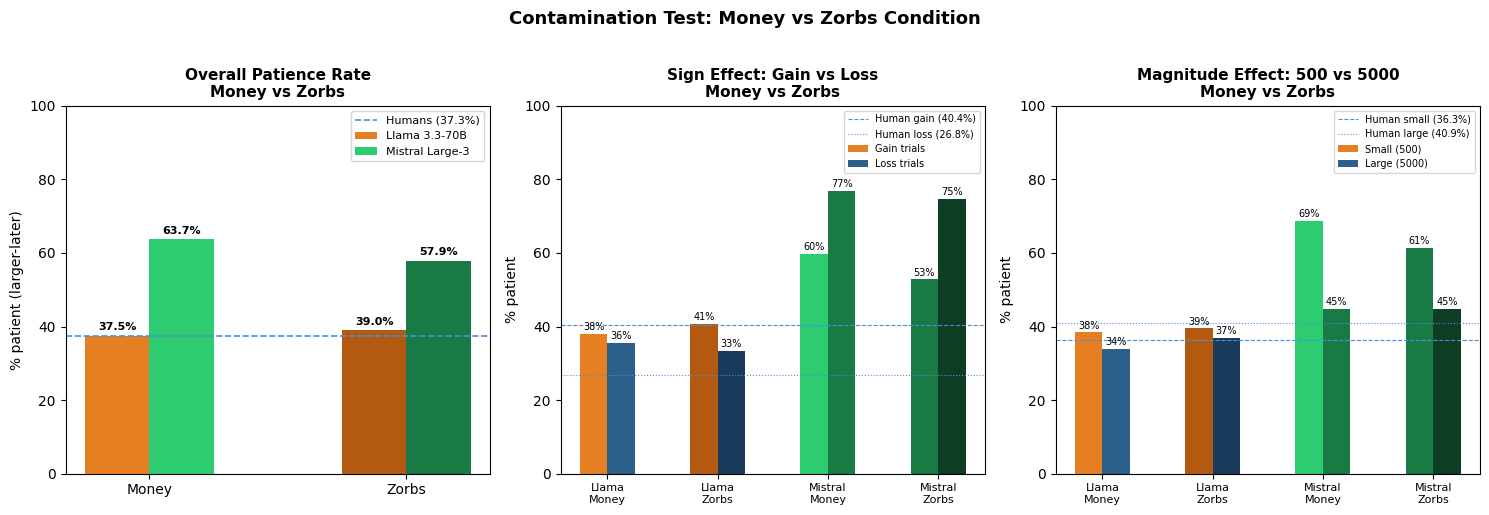

Saved to zorbs_comparison.png


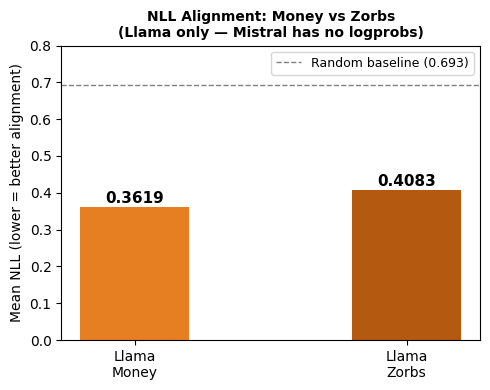

Saved to zorbs_nll_comparison.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x = np.arange(2)        # money, zorbs
width = 0.25
colors_money = ["#e67e22", "#2ecc71"]   # Llama orange, Mistral green
colors_zorbs = ["#b35a10", "#1a7a45"]   # darker shades for zorbs

# ── Figure 1: Overall patience rate ──
ax1 = axes[0]
llama_vals   = [llama_m_overall,   llama_z_overall]
mistral_vals = [mistral_m_overall, mistral_z_overall]
human_line   = 37.3

bars1 = ax1.bar(x - width/2, llama_vals,   width, label="Llama 3.3-70B",
                color=["#e67e22", "#b35a10"])
bars2 = ax1.bar(x + width/2, mistral_vals, width, label="Mistral Large-3",
                color=["#2ecc71", "#1a7a45"])
ax1.axhline(human_line, color="#4a90d9", linestyle="--",
            linewidth=1.2, label=f"Humans ({human_line}%)")
ax1.set_xticks(x)
ax1.set_xticklabels(["Money", "Zorbs"], fontsize=10)
ax1.set_ylabel("% patient (larger-later)", fontsize=10)
ax1.set_title("Overall Patience Rate\nMoney vs Zorbs", fontsize=11, fontweight="bold")
ax1.set_ylim(0, 100)
ax1.legend(fontsize=8)
for bar in list(bars1) + list(bars2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{bar.get_height():.1f}%", ha="center", fontsize=8, fontweight="bold")

# ── Figure 2: Sign effect ──
ax2 = axes[1]
x4 = np.arange(4)
labels4 = ["Llama\nMoney", "Llama\nZorbs", "Mistral\nMoney", "Mistral\nZorbs"]
gain_vals = [llama_m_gain, llama_z_gain, mistral_m_gain, mistral_z_gain]
loss_vals = [llama_m_loss, llama_z_loss, mistral_m_loss, mistral_z_loss]
bar_colors = ["#e67e22", "#b35a10", "#2ecc71", "#1a7a45"]

b1 = ax2.bar(x4 - width/2, gain_vals, width, label="Gain trials", color=bar_colors)
b2 = ax2.bar(x4 + width/2, loss_vals, width, label="Loss trials",
             color=["#2c5f8a", "#1a3a5c", "#1a7a45", "#0d3d22"])
ax2.axhline(40.4, color="#4a90d9", linestyle="--", linewidth=0.8, label="Human gain (40.4%)")
ax2.axhline(26.8, color="#4a90d9", linestyle=":",  linewidth=0.8, label="Human loss (26.8%)")
ax2.set_xticks(x4)
ax2.set_xticklabels(labels4, fontsize=8)
ax2.set_ylabel("% patient", fontsize=10)
ax2.set_title("Sign Effect: Gain vs Loss\nMoney vs Zorbs", fontsize=11, fontweight="bold")
ax2.set_ylim(0, 100)
ax2.legend(fontsize=7)
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.0f}%", ha="center", fontsize=7)

# ── Figure 3: Magnitude effect ──
ax3 = axes[2]
small_vals = [llama_m_small, llama_z_small, mistral_m_small, mistral_z_small]
large_vals = [llama_m_large, llama_z_large, mistral_m_large, mistral_z_large]

b3 = ax3.bar(x4 - width/2, small_vals, width, label="Small (500)", color=bar_colors)
b4 = ax3.bar(x4 + width/2, large_vals, width, label="Large (5000)",
             color=["#2c5f8a", "#1a3a5c", "#1a7a45", "#0d3d22"])
ax3.axhline(36.3, color="#4a90d9", linestyle="--", linewidth=0.8, label="Human small (36.3%)")
ax3.axhline(40.9, color="#4a90d9", linestyle=":",  linewidth=0.8, label="Human large (40.9%)")
ax3.set_xticks(x4)
ax3.set_xticklabels(labels4, fontsize=8)
ax3.set_ylabel("% patient", fontsize=10)
ax3.set_title("Magnitude Effect: 500 vs 5000\nMoney vs Zorbs", fontsize=11, fontweight="bold")
ax3.set_ylim(0, 100)
ax3.legend(fontsize=7)
for bar in list(b3) + list(b4):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.0f}%", ha="center", fontsize=7)

plt.suptitle("Contamination Test: Money vs Zorbs Condition",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("zorbs_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to zorbs_comparison.png")

# ── NLL comparison for Llama ──
fig2, ax = plt.subplots(figsize=(5, 4))
nll_vals = [llama_m_nll, llama_z_nll]
bars = ax.bar(["Llama\nMoney", "Llama\nZorbs"], nll_vals,
              color=["#e67e22", "#b35a10"], width=0.4)
ax.axhline(0.6931, color="gray", linestyle="--",
           linewidth=1.0, label="Random baseline (0.693)")
ax.set_ylabel("Mean NLL (lower = better alignment)", fontsize=10)
ax.set_title("NLL Alignment: Money vs Zorbs\n(Llama only — Mistral has no logprobs)",
             fontsize=10, fontweight="bold")
ax.set_ylim(0, 0.8)
for bar, val in zip(bars, nll_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("zorbs_nll_comparison.png", dpi=150)
plt.show()
print("Saved to zorbs_nll_comparison.png")

In [ ]:
## Frontier Models — Claude and GPT

### Context
Access granted after draft poster submission (Apr 5).
We run both frontier models on the money condition and the zorbs condition
using the same pipeline as Llama and Mistral.

### Models
- `claude-sonnet-4-5` — Anthropic
- `gpt-5.4` — OpenAI

### Key difference from open-weight models
Neither frontier model returns log probabilities on this endpoint,
so we use binary choice analysis only — the same approach as Mistral.
NLL scoring is not available for these models.

### Order of operations
1. Single-trial test — confirm both models respond correctly
2. Money condition — 50 participants each
3. Zorbs condition — 50 participants each
4. Update CSV loader cell with four new files
5. Re-run analysis and plots with all four models

In [22]:
# ── Frontier model setup ──
CLAUDE_MODEL = "claude-sonnet-4-5"
GPT_MODEL    = "gpt-5.4"

# ── Single trial test before committing to full runs ──
sample_trials = extract_trials(itc_data[0]["text"])
test_prompt, test_human = sample_trials[0]

claude_response = ask_frontier_model(test_prompt, CLAUDE_MODEL)
gpt_response    = ask_frontier_model(test_prompt, GPT_MODEL)

print(f"Test prompt (last line):")
print(test_prompt.split('\n')[-1])
print(f"Human chose:  {test_human}")
print(f"Claude chose: {claude_response}")
print(f"GPT chose:    {gpt_response}")

Test prompt (last line):
You have the choice between receiving 500$ immediately (press G) or receiving 550$ in one year (press C). You press
Human chose:  G
Claude chose: C
GPT chose:    C


In [20]:
# ── Diagnose GPT-5.4 raw response ──
valid_options = get_valid_options(test_prompt)
options_str = " or ".join(valid_options)

response = client.chat.completions.create(
    model=GPT_MODEL,
    messages=[
        {
            "role": "system",
            "content": (f"You are participating in a psychology experiment. "
                        f"You must respond with ONLY a single letter ({options_str}). "
                        f"No explanation. No punctuation. Just the letter.")
        },
        {
            "role": "user",
            "content": test_prompt + "\nYou press <<"
        }
    ],
    max_tokens=3,
    temperature=1
)

raw = response.choices[0].message.content
print(f"Valid options: {valid_options}")
print(f"Raw response: '{raw}'")
print(f"Response length: {len(raw)}")
print(f"Character codes: {[ord(c) for c in raw]}")

Valid options: ['C', 'G']
Raw response: ''
Response length: 0
Character codes: []


In [ ]:
## Frontier Model Runs — Claude and GPT (Money + Zorbs)

### What these cells do

These four cells run the full 50-participant experiment on both frontier models
across both conditions. Each cell takes approximately 6-8 minutes. Run them
one at a time and wait for each to complete before starting the next.

| Cell | Model | Condition | Expected output |
|---|---|---|---|
| 1 | claude-sonnet-4-5 | Money | 598 trials, 0 missing |
| 2 | gpt-5.4 | Money | 598 trials, 0 missing |
| 3 | claude-sonnet-4-5 | Zorbs | 598 trials, 0 missing |
| 4 | gpt-5.4 | Zorbs | 598 trials, 0 missing |

### Key differences from open-weight runs

- No NLL scoring — neither frontier model returns log probabilities on this
  endpoint, so we use binary choice analysis only (same approach as Mistral)
- temperature=1 — GPT-5.4 does not support temperature=0.0; Claude runs at
  temperature=1 for consistency. This introduces minor stochasticity and is
  noted in the limitations section.
- max_tokens=50 — GPT-5.4 requires more token budget than open-weight models
  to produce any output; the parser still extracts only the first valid letter.

### ⚠️ Skip on restart

Once all four CSVs are saved, never run these cells again.
Load results using the CSV loader cell instead.

In [23]:
## Claude Money
df_claude_money = run_experiment_frontier(
    itc_data, CLAUDE_MODEL, n_participants=50
)
df_claude_money.to_csv("results_claude_money_50p.csv", index=False)
print(f"Done. {len(df_claude_money)} trials, "
      f"{df_claude_money['model_choice'].isna().sum()} missing")

Running claude-sonnet-4-5: 100%|████████████████| 50/50 [12:12<00:00, 14.64s/it]

Done. 598 trials, 0 missing


In [25]:
## GPT Money
df_gpt_money = run_experiment_frontier(
    itc_data, GPT_MODEL, n_participants=50
)
df_gpt_money.to_csv("results_gpt_money_50p.csv", index=False)
print(f"Done. {len(df_gpt_money)} trials, "
      f"{df_gpt_money['model_choice'].isna().sum()} missing")

Running gpt-5.4: 100%|██████████████████████████| 50/50 [09:21<00:00, 11.23s/it]

Done. 598 trials, 0 missing


In [24]:
# Claude Zorbs
df_claude_zorbs = run_experiment_zorbs_frontier(
    itc_data, CLAUDE_MODEL, n_participants=50
)
df_claude_zorbs.to_csv("results_claude_zorbs_50p.csv", index=False)
print(f"Done. {len(df_claude_zorbs)} trials, "
      f"{df_claude_zorbs['model_choice'].isna().sum()} missing")

Zorbs/claude-sonnet-4-5: 100%|██████████████████| 50/50 [12:22<00:00, 14.85s/it]

Done. 598 trials, 0 missing


In [26]:
# GPT Zorbs
df_gpt_zorbs = run_experiment_zorbs_frontier(
    itc_data, GPT_MODEL, n_participants=50
)
df_gpt_zorbs.to_csv("results_gpt_zorbs_50p.csv", index=False)
print(f"Done. {len(df_gpt_zorbs)} trials, "
      f"{df_gpt_zorbs['model_choice'].isna().sum()} missing")

Zorbs/gpt-5.4: 100%|████████████████████████████| 50/50 [09:11<00:00, 11.02s/it]

Done. 598 trials, 0 missing


In [ ]:
## Cell 15 — Full Results Analysis: All Models, Money and Zorbs

### What this cell computes

This cell applies the labelling and patience-rate functions to all eight
dataframes — four models × two conditions — and prints a single unified
comparison table.

Each row shows patience rate broken down by:
- **Overall** — aggregate choice across all 598 trials
- **Gain** — trials framed as receiving money
- **Loss** — trials framed as paying money (sign effect)
- **Small** — trials involving 500-unit amounts (magnitude effect)
- **Large** — trials involving 5000-unit amounts (magnitude effect)

### How to read the table

The human row is your ground truth. For each model, read across:
- Does the overall rate match humans?
- Does the gain/loss gap go in the right direction? (humans: gain > loss)
- Does the small/large gap go in the right direction? (humans: large > small)

Then compare money vs zorbs rows for each model to assess contamination.
A shift of <5% is negligible. A shift of >10% warrants scientific attention.

### NLL reminder

NLL is only available for Llama because it is the only model on this
endpoint that returns log probabilities. All frontier models and Mistral
are evaluated on binary choice only.

In [27]:
# ── Label all eight dataframes ──
df_llama_m    = label_dataframe(df_llama_full)
df_mistral_m  = label_dataframe(df_mistral_full)
df_claude_m   = label_dataframe(df_claude_money)
df_gpt_m      = label_dataframe(df_gpt_money)

df_llama_z    = label_dataframe(df_llama_zorbs)
df_mistral_z  = label_dataframe(df_mistral_zorbs)
df_claude_z   = label_dataframe(df_claude_zorbs)
df_gpt_z      = label_dataframe(df_gpt_zorbs)

# ── Compute patience rates for all eight ──
llama_m_overall,   llama_m_gain,   llama_m_loss,   llama_m_small,   llama_m_large   = patience_rates(df_llama_m)
mistral_m_overall, mistral_m_gain, mistral_m_loss, mistral_m_small, mistral_m_large = patience_rates(df_mistral_m)
claude_m_overall,  claude_m_gain,  claude_m_loss,  claude_m_small,  claude_m_large  = patience_rates(df_claude_m)
gpt_m_overall,     gpt_m_gain,     gpt_m_loss,     gpt_m_small,     gpt_m_large     = patience_rates(df_gpt_m)

llama_z_overall,   llama_z_gain,   llama_z_loss,   llama_z_small,   llama_z_large   = patience_rates(df_llama_z)
mistral_z_overall, mistral_z_gain, mistral_z_loss, mistral_z_small, mistral_z_large = patience_rates(df_mistral_z)
claude_z_overall,  claude_z_gain,  claude_z_loss,  claude_z_small,  claude_z_large  = patience_rates(df_claude_z)
gpt_z_overall,     gpt_z_gain,     gpt_z_loss,     gpt_z_small,     gpt_z_large     = patience_rates(df_gpt_z)

# ── NLL for Llama only ──
llama_m_nll, llama_m_n = mean_nll_filtered(df_llama_m)
llama_z_nll, llama_z_n = mean_nll_filtered(df_llama_z)

# ── Print full comparison table ──
HUMAN = dict(overall=37.3, gain=40.4, loss=26.8, small=36.3, large=40.9)

print("=" * 65)
print("FULL RESULTS — ALL MODELS — MONEY AND ZORBS CONDITIONS")
print("=" * 65)

header = f"{'':28s} {'Overall':>7} {'Gain':>7} {'Loss':>7} {'Small':>7} {'Large':>7}"
print(header)
print("-" * 65)

print(f"{'Humans (Psych-101)':28s} {HUMAN['overall']:>7.1f}% {HUMAN['gain']:>7.1f}% {HUMAN['loss']:>7.1f}% {HUMAN['small']:>7.1f}% {HUMAN['large']:>7.1f}%")
print()
print(f"{'Llama — Money':28s} {llama_m_overall:>7.1f}% {llama_m_gain:>7.1f}% {llama_m_loss:>7.1f}% {llama_m_small:>7.1f}% {llama_m_large:>7.1f}%")
print(f"{'Llama — Zorbs':28s} {llama_z_overall:>7.1f}% {llama_z_gain:>7.1f}% {llama_z_loss:>7.1f}% {llama_z_small:>7.1f}% {llama_z_large:>7.1f}%")
print()
print(f"{'Mistral — Money':28s} {mistral_m_overall:>7.1f}% {mistral_m_gain:>7.1f}% {mistral_m_loss:>7.1f}% {mistral_m_small:>7.1f}% {mistral_m_large:>7.1f}%")
print(f"{'Mistral — Zorbs':28s} {mistral_z_overall:>7.1f}% {mistral_z_gain:>7.1f}% {mistral_z_loss:>7.1f}% {mistral_z_small:>7.1f}% {mistral_z_large:>7.1f}%")
print()
print(f"{'Claude — Money':28s} {claude_m_overall:>7.1f}% {claude_m_gain:>7.1f}% {claude_m_loss:>7.1f}% {claude_m_small:>7.1f}% {claude_m_large:>7.1f}%")
print(f"{'Claude — Zorbs':28s} {claude_z_overall:>7.1f}% {claude_z_gain:>7.1f}% {claude_z_loss:>7.1f}% {claude_z_small:>7.1f}% {claude_z_large:>7.1f}%")
print()
print(f"{'GPT-5.4 — Money':28s} {gpt_m_overall:>7.1f}% {gpt_m_gain:>7.1f}% {gpt_m_loss:>7.1f}% {gpt_m_small:>7.1f}% {gpt_m_large:>7.1f}%")
print(f"{'GPT-5.4 — Zorbs':28s} {gpt_z_overall:>7.1f}% {gpt_z_gain:>7.1f}% {gpt_z_loss:>7.1f}% {gpt_z_small:>7.1f}% {gpt_z_large:>7.1f}%")

print()
print("=" * 65)
print("NLL (Llama only — other models do not return logprobs)")
print("=" * 65)
print(f"Random baseline:  0.6931")
print(f"Llama money NLL:  {llama_m_nll:.4f} ({llama_m_n} trials)")
print(f"Llama zorbs NLL:  {llama_z_nll:.4f} ({llama_z_n} trials)")

FULL RESULTS — ALL MODELS — MONEY AND ZORBS CONDITIONS
                             Overall    Gain    Loss   Small   Large
-----------------------------------------------------------------
Humans (Psych-101)              37.3%    40.4%    26.8%    36.3%    40.9%

Llama — Money                   37.5%    38.0%    35.5%    38.4%    33.9%
Llama — Zorbs                   39.0%    40.7%    33.3%    39.5%    37.0%

Mistral — Money                 63.7%    59.8%    76.8%    68.8%    44.9%
Mistral — Zorbs                 57.9%    52.8%    74.6%    61.4%    44.9%

Claude — Money                  59.4%    65.0%    40.6%    57.7%    65.4%
Claude — Zorbs                  76.6%    77.4%    73.9%    76.4%    77.2%

GPT-5.4 — Money                 67.4%    65.9%    72.5%    68.6%    63.0%
GPT-5.4 — Zorbs                 72.7%    75.7%    63.0%    76.0%    60.6%

NLL (Llama only — other models do not return logprobs)
Random baseline:  0.6931
Llama money NLL:  0.3619 (391 trials)
Llama zorbs NLL:  0.4

In [ ]:
## Cell 16 — Comparison Plots: All Models, Money and Zorbs

### What these figures show

Three plots presenting the full four-model comparison:

**Figure 1 — Overall patience rate**
One bar per model for the money condition, paired with a darker bar for
the zorbs condition. The human rate (37.3%) is shown as a dashed blue
line. Tells you immediately which models are patient-like and which
overshoot.

**Figure 2 — Sign effect, open-weight models**
Llama and Mistral, money and zorbs, split by gain vs loss trials.
Solid bars = gain trials. Faded bars = loss trials.
Human reference lines show where the bars should land if a model
reproduces the human sign effect. Humans show a 13.6pt gain/loss gap —
look for which models reproduce this direction and magnitude.

**Figure 3 — Sign effect, frontier models**
Same structure as Figure 2 but for Claude and GPT-5.4.
The key question: do frontier models — with more parameters and more
training data — reproduce the human sign effect better than open-weight
models, or do they diverge in different ways?

### What to look for across all three

- Bar height relative to the human reference lines → computational alignment
- Gap between gain and loss bars → algorithmic alignment (sign effect)
- Difference between money and zorbs bars → contamination sensitivity
- Whether frontier models cluster closer to humans than open-weight models

### These figures are for analysis — poster versions will be simplified

The poster will show cleaner versions of the most important comparisons.
These full figures go in the appendix or are used to extract the
key numbers for the poster narrative.

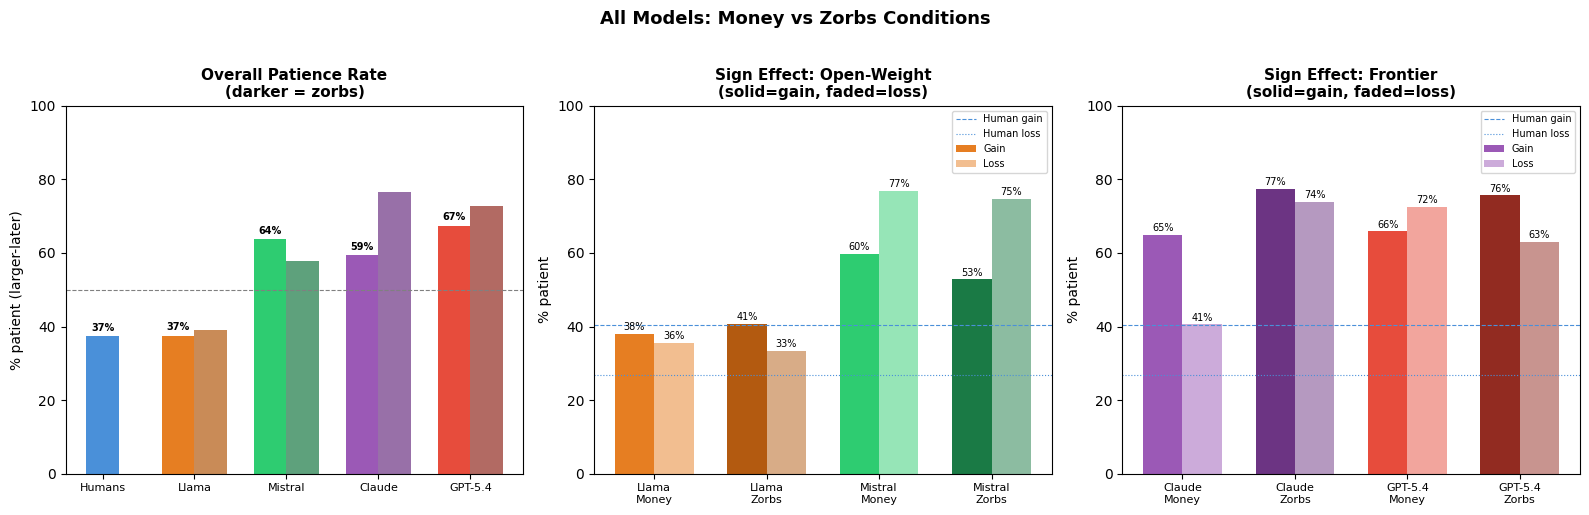

Saved to all_models_comparison.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# ── Shared setup ──
models      = ["Humans", "Llama", "Mistral", "Claude", "GPT-5.4"]
colors_money = ["#4a90d9", "#e67e22", "#2ecc71", "#9b59b6", "#e74c3c"]
colors_zorbs = ["#2c5f8a", "#b35a10", "#1a7a45", "#6c3483", "#922b21"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Figure 1: Overall patience rate ──
ax1 = axes[0]
x = np.arange(5)
width = 0.35
money_vals = [37.3, llama_m_overall, mistral_m_overall, claude_m_overall, gpt_m_overall]
zorbs_vals = [None, llama_z_overall, mistral_z_overall, claude_z_overall, gpt_z_overall]

bars1 = ax1.bar(x[0], money_vals[0], width, color=colors_money[0], label="Humans")
for i in range(1, 5):
    ax1.bar(x[i] - width/2, money_vals[i], width,
            color=colors_money[i], label=f"{models[i]} Money")
    ax1.bar(x[i] + width/2, zorbs_vals[i], width,
            color=colors_zorbs[i], label=f"{models[i]} Zorbs", alpha=0.7)

ax1.axhline(50, color="gray", linestyle="--", linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=8)
ax1.set_ylabel("% patient (larger-later)", fontsize=10)
ax1.set_title("Overall Patience Rate\n(darker = zorbs)", fontsize=11, fontweight="bold")
ax1.set_ylim(0, 100)
for i, v in enumerate(money_vals):
    ax1.text(x[i] - (width/2 if i > 0 else 0), v + 1.5,
             f"{v:.0f}%", ha="center", fontsize=7, fontweight="bold")

# ── Figure 2: Sign effect ──
ax2 = axes[1]
x4 = np.arange(4)
labels4 = ["Llama\nMoney", "Llama\nZorbs", "Mistral\nMoney", "Mistral\nZorbs"]
gain_vals_ow = [llama_m_gain, llama_z_gain, mistral_m_gain, mistral_z_gain]
loss_vals_ow = [llama_m_loss, llama_z_loss, mistral_m_loss, mistral_z_loss]
bar_colors_ow = [colors_money[1], colors_zorbs[1], colors_money[2], colors_zorbs[2]]

b1 = ax2.bar(x4 - width/2, gain_vals_ow, width, color=bar_colors_ow, label="Gain")
b2 = ax2.bar(x4 + width/2, loss_vals_ow, width, color=bar_colors_ow, alpha=0.5, label="Loss")
ax2.axhline(40.4, color="#4a90d9", linestyle="--", linewidth=0.8, label="Human gain")
ax2.axhline(26.8, color="#4a90d9", linestyle=":",  linewidth=0.8, label="Human loss")
ax2.set_xticks(x4)
ax2.set_xticklabels(labels4, fontsize=8)
ax2.set_ylabel("% patient", fontsize=10)
ax2.set_title("Sign Effect: Open-Weight\n(solid=gain, faded=loss)", fontsize=11, fontweight="bold")
ax2.set_ylim(0, 100)
ax2.legend(fontsize=7)
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.0f}%", ha="center", fontsize=7)

# ── Figure 3: Sign effect frontier ──
ax3 = axes[2]
labels4f = ["Claude\nMoney", "Claude\nZorbs", "GPT-5.4\nMoney", "GPT-5.4\nZorbs"]
gain_vals_f = [claude_m_gain, claude_z_gain, gpt_m_gain, gpt_z_gain]
loss_vals_f = [claude_m_loss, claude_z_loss, gpt_m_loss, gpt_z_loss]
bar_colors_f = [colors_money[3], colors_zorbs[3], colors_money[4], colors_zorbs[4]]

b3 = ax3.bar(x4 - width/2, gain_vals_f, width, color=bar_colors_f, label="Gain")
b4 = ax3.bar(x4 + width/2, loss_vals_f, width, color=bar_colors_f, alpha=0.5, label="Loss")
ax3.axhline(40.4, color="#4a90d9", linestyle="--", linewidth=0.8, label="Human gain")
ax3.axhline(26.8, color="#4a90d9", linestyle=":",  linewidth=0.8, label="Human loss")
ax3.set_xticks(x4)
ax3.set_xticklabels(labels4f, fontsize=8)
ax3.set_ylabel("% patient", fontsize=10)
ax3.set_title("Sign Effect: Frontier\n(solid=gain, faded=loss)", fontsize=11, fontweight="bold")
ax3.set_ylim(0, 100)
ax3.legend(fontsize=7)
for bar in list(b3) + list(b4):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.0f}%", ha="center", fontsize=7)

plt.suptitle("All Models: Money vs Zorbs Conditions",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to all_models_comparison.png")